In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load Dataset & Feature Engineering
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]
df["IsCancelled"] = df["InvoiceNo"].str.startswith("C", na=False).astype(int)

# Filtered/sample subset for clean visualization (removes extreme retail outliers)
sample_df = df[
    (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0)
    & (df["Quantity"] <= 50)
    & (df["UnitPrice"] <= 20)
].sample(2000, random_state=42)

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  TotalSales  \
0  12/1/2010 8:26       2.55     17850.0  United Kingdom       15.30   
1  12/1/2010 8:26       3.39     17850.0  United Kingdom       20.34   
2  12/1/2010 8:26       2.75     17850.0  United Kingdom       22.00   
3  12/1/2010 8:26       3.39     17850.0  United Kingdom       20.34   
4  12/1/2010 8:26       3.39     17850.0  United Kingdom       20.34   

   IsCancelled  
0            0  
1            0  
2            0  
3            0  
4            0  


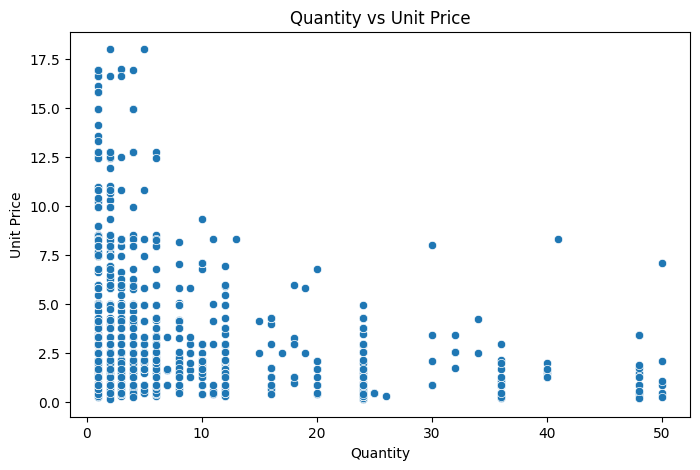

In [10]:
# 2. Scatter Plot: Quantity vs Unit Price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_df, x="Quantity", y="UnitPrice")
plt.title("Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.show()

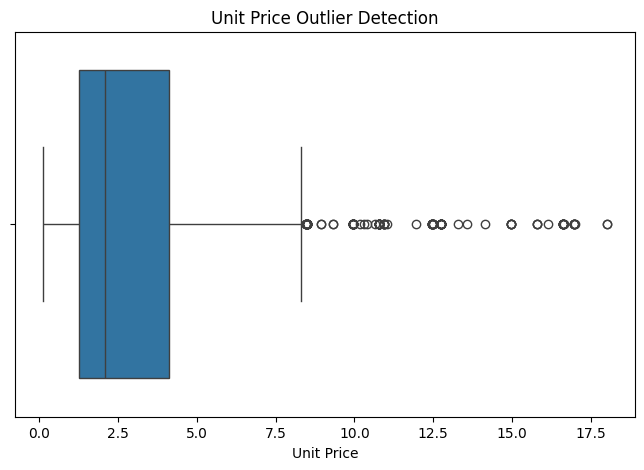

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=sample_df["UnitPrice"])
plt.title("Unit Price Outlier Detection")
plt.xlabel("Unit Price")
plt.show()

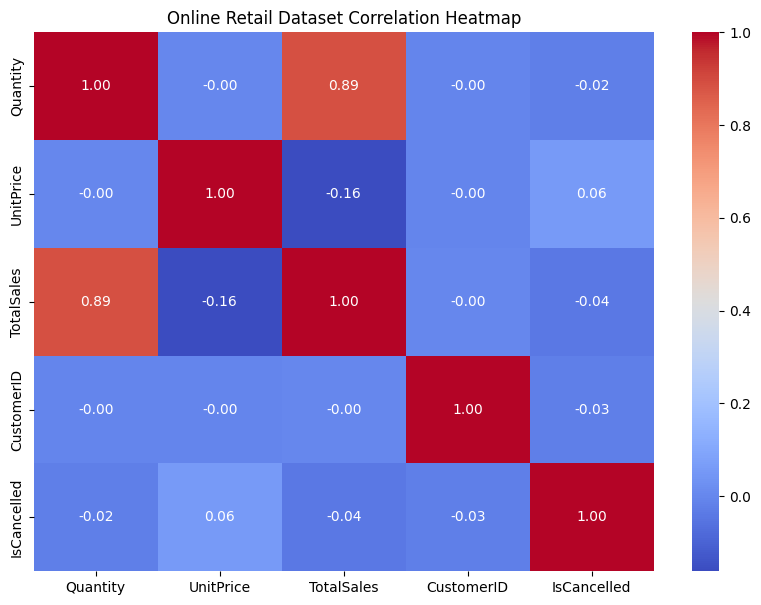

In [7]:
plt.figure(figsize=(10, 7))
corr = df[["Quantity", "UnitPrice", "TotalSales", "CustomerID", "IsCancelled"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Online Retail Dataset Correlation Heatmap")
plt.show()

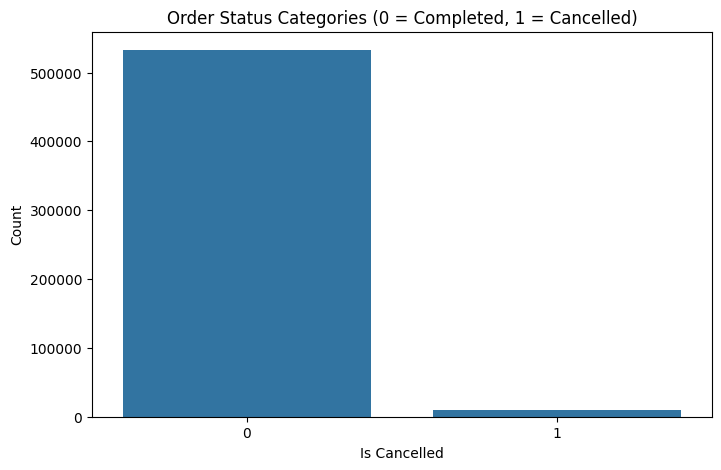

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="IsCancelled")
plt.title("Order Status Categories (0 = Completed, 1 = Cancelled)")
plt.xlabel("Is Cancelled")
plt.ylabel("Count")
plt.show()

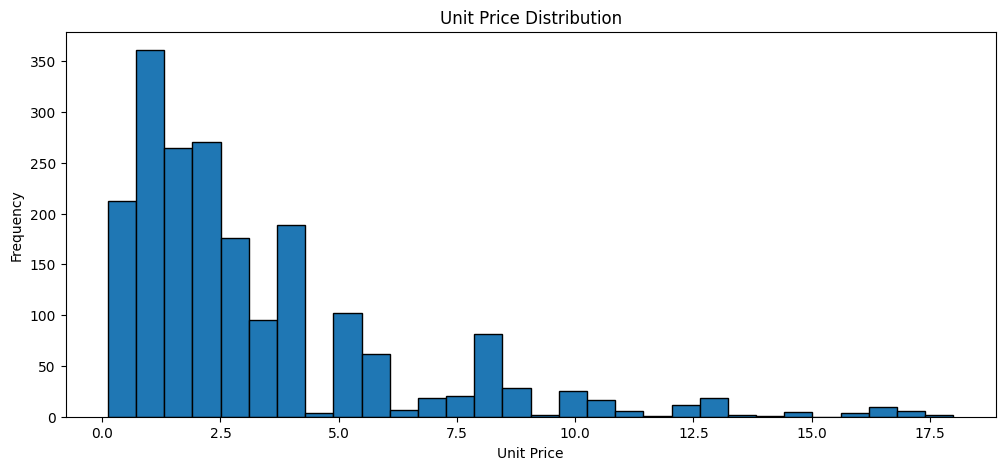

In [9]:
plt.figure(figsize=(12, 5))
plt.hist(sample_df["UnitPrice"], bins=30, edgecolor="black")
plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

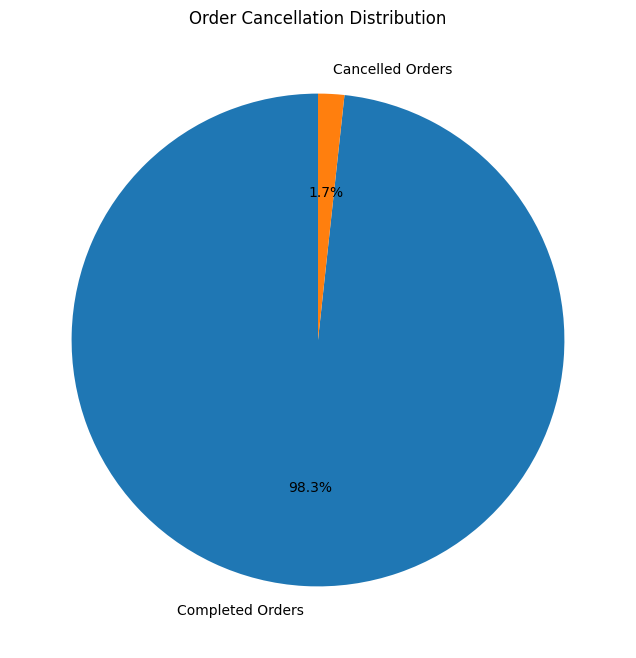

In [11]:
cancellation_counts = df["IsCancelled"].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(
    cancellation_counts,
    labels=["Completed Orders", "Cancelled Orders"],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Order Cancellation Distribution")
plt.show()

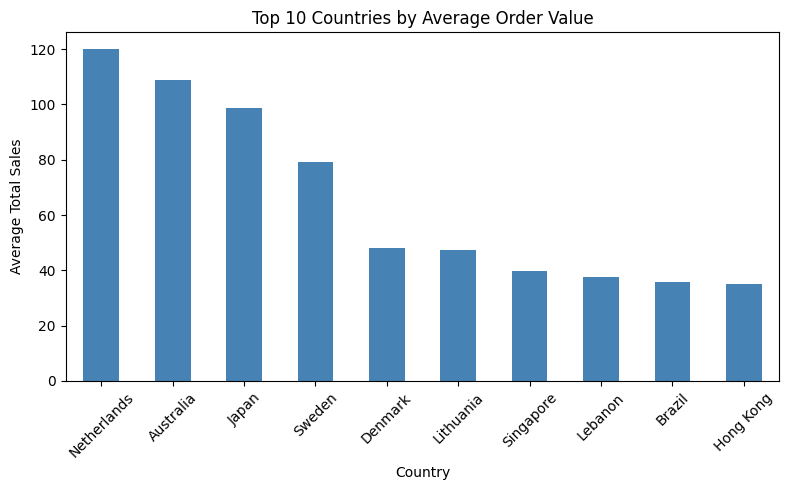

In [12]:
top_countries = (
    df.groupby("Country")["TotalSales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(8, 5))
top_countries.plot(kind="bar", color="steelblue")
plt.title("Top 10 Countries by Average Order Value")
plt.ylabel("Average Total Sales")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

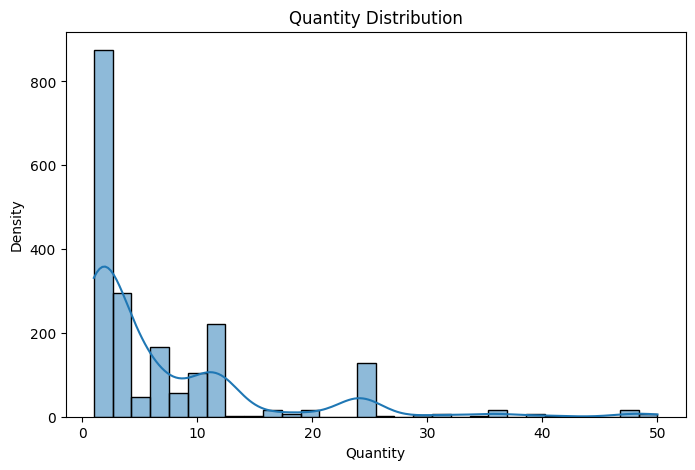

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(sample_df["Quantity"], bins=30, kde=True)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Density")
plt.show()

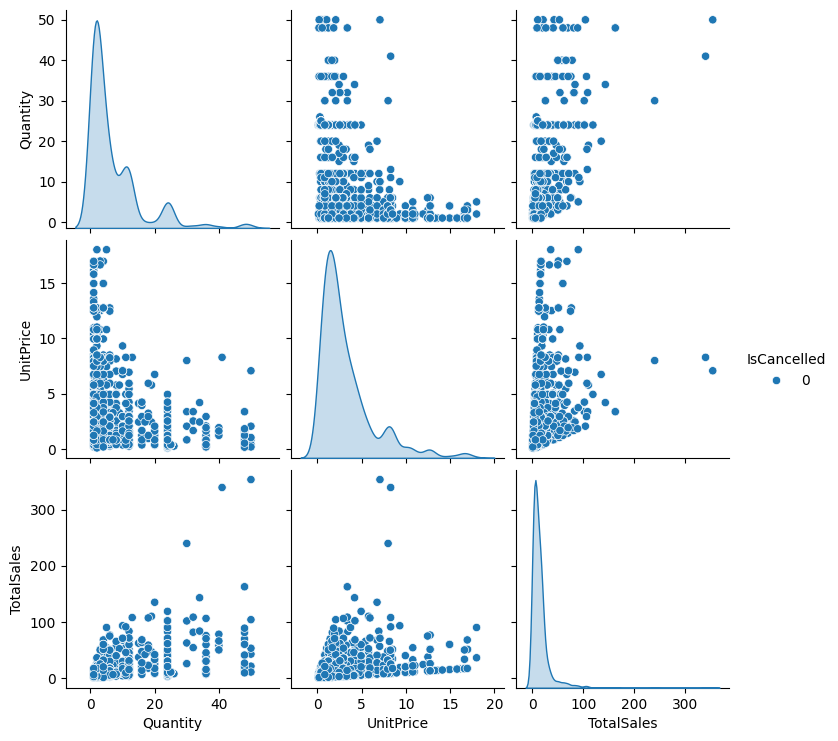

In [14]:
sns.pairplot(
    sample_df[["Quantity", "UnitPrice", "TotalSales", "IsCancelled"]],
    hue="IsCancelled",
)
plt.show()

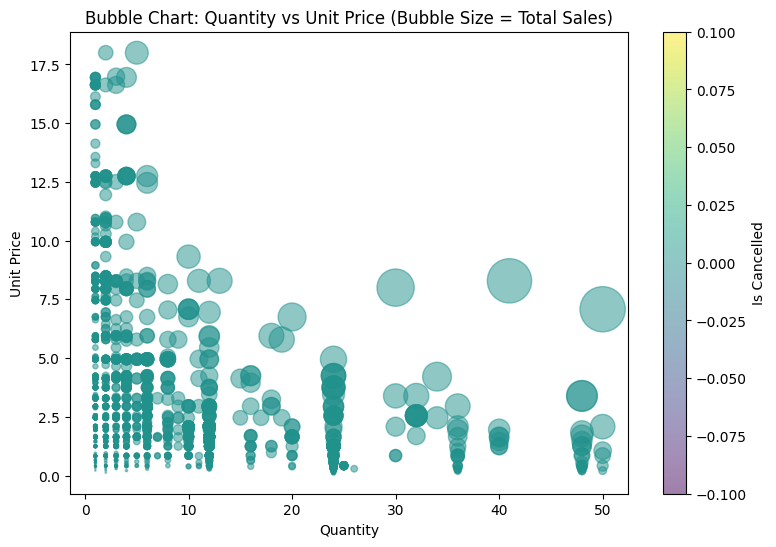

In [15]:
plt.figure(figsize=(9, 6))
plt.scatter(
    sample_df["Quantity"],
    sample_df["UnitPrice"],
    s=sample_df["TotalSales"] * 3,
    alpha=0.5,
    c=sample_df["IsCancelled"],
    cmap="viridis",
)
plt.colorbar(label="Is Cancelled")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.title("Bubble Chart: Quantity vs Unit Price (Bubble Size = Total Sales)")
plt.show()

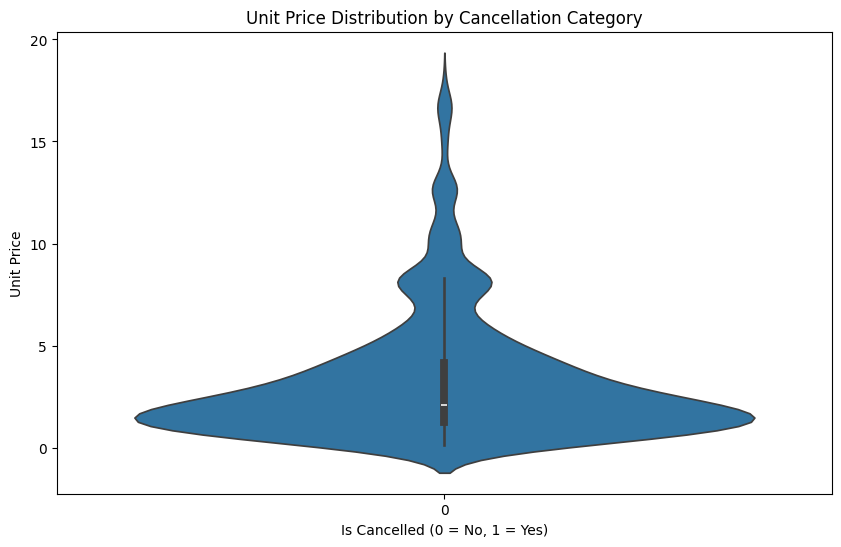

In [16]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=sample_df, x="IsCancelled", y="UnitPrice")
plt.title("Unit Price Distribution by Cancellation Category")
plt.xlabel("Is Cancelled (0 = No, 1 = Yes)")
plt.ylabel("Unit Price")
plt.show()

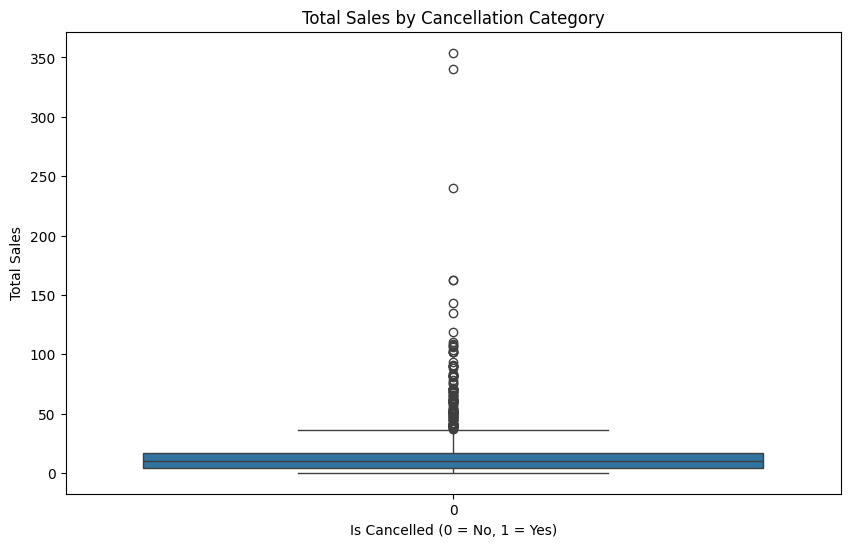

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=sample_df, x="IsCancelled", y="TotalSales")
plt.title("Total Sales by Cancellation Category")
plt.xlabel("Is Cancelled (0 = No, 1 = Yes)")
plt.ylabel("Total Sales")
plt.show()